In [1]:
# This script loads all 0-hour MetUM archive (*000.pp) files in a specified 
# directory (inputdir), and then prints out a list of all the cubes
# containing data fields in those loaded files, along with data dimensions and units.
# It then goes through an exercise of reading in and plotting surface altitude
# data, highlighting issues along the way and solutions for them.

# import libraries
import glob
import iris
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# specify the directory containing the MetUM archive files
inputdir='/gws/ssde/j25b/team_x/users/kahern/hackathon/metum/20250629T1200Z'
inputdir='/work/scratch-pw5/kahern/teamx/metum/20250722T1200Z/u-dr361'

In [3]:
# use pattern matching to find any 0-hour MetUM archives
# in the specified input directory, and then load those files.
allfiles = glob.glob(f"{inputdir}/*000.pp")
allfiles.sort()

In [4]:
# when the files are loaded by iris, it returns a list
# of iris cubes. Each cube contains a field from the model,
# along with metadata and routines that might help with
# data manipulation.
allcubes = iris.load(allfiles)

/home/users/kahern/conda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/users/kahern/conda/lib/python3.12/site-packages/iris/fileformats/rules.py:45: IrisUserWarning: Multiple reference cubes for orography
  warnings.warn(


In [5]:
# print out a list of information for the list of cubes,
# with each item including a name of the model output field, units, and dimensions.
print(allcubes)

0: m01s09i202 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
1: m01s09i202 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
2: cloud_area_fraction_assuming_maximum_random_overlap / (1) (time: 13; grid_latitude: 368; grid_longitude: 432)
3: cloud_area_fraction_assuming_maximum_random_overlap / (1) (time: 13; grid_latitude: 368; grid_longitude: 432)
4: m01s30i295 / (unknown)              (time: 12; pressure: 16; grid_latitude: 368; grid_longitude: 432)
5: m01s30i295 / (unknown)              (time: 12; pressure: 16; grid_latitude: 368; grid_longitude: 432)
6: m01s30i296 / (unknown)              (time: 12; pressure: 16; grid_latitude: 368; grid_longitude: 432)
7: m01s30i296 / (unknown)              (time: 12; pressure: 16; grid_latitude: 368; grid_longitude: 432)
8: m01s20i110 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
9: m01s20i111 / (unknown)              (time: 12; grid_latitude: 368; grid_longit

/home/users/kahern/conda/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/kahern/conda/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/kahern/conda/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precisio

In [6]:
# MetUM data are split into several archive files, which
# can contain different data for different purposes.
# For this case, we have archive files for the IOPs we're interested in
# that have similar filenames, but their endings 
# vary by the first forecast hour in the file (the 3-digit number
# right before the file extension) and a string before that---
# we'll call that string the suffix.
# Let's see what's in the files according to what suffix
# it has.
sufflist = ['pa', 'pexpa', 'pexpb', 'pexpc', 'pexpe', 'pverb']
for suffix in sufflist:
    flist = glob.glob(f"{inputdir}/*{suffix}000.pp")
    flist.sort()
    allcubes = iris.load(flist)
    print('')
    print(f"Archives with {suffix} suffix:")
    print(allcubes)


Archives with pa suffix:
0: m01s09i202 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
1: cloud_area_fraction_assuming_maximum_random_overlap / (1) (time: 12; grid_latitude: 368; grid_longitude: 432)
2: m01s30i295 / (unknown)              (time: 12; pressure: 2; grid_latitude: 368; grid_longitude: 432)
3: m01s30i296 / (unknown)              (time: 12; pressure: 2; grid_latitude: 368; grid_longitude: 432)
4: m01s20i110 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
5: m01s20i111 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
6: m01s20i112 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
7: m01s20i113 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
8: m01s20i114 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
9: m01s20i115 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
10: m01s20i116 /

/home/users/kahern/conda/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/kahern/conda/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/kahern/conda/lib/python3.12/site-packages/iris/fileformats/rules.py:371: IrisUserWarning: Unable to create instance of HybridHeightFactory. The sour


Archives with pexpa suffix:
0: m01s09i202 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
1: cloud_area_fraction_assuming_maximum_random_overlap / (1) (time: 12; grid_latitude: 368; grid_longitude: 432)
2: m01s30i295 / (unknown)              (time: 12; pressure: 2; grid_latitude: 368; grid_longitude: 432)
3: m01s30i296 / (unknown)              (time: 12; pressure: 2; grid_latitude: 368; grid_longitude: 432)
4: m01s20i110 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
5: m01s20i111 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
6: m01s20i112 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
7: m01s20i113 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
8: m01s20i114 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
9: m01s20i115 / (unknown)              (time: 12; grid_latitude: 368; grid_longitude: 432)
10: m01s20i11

In [7]:
# Let's try to visualize the surface altitude field. 
# We can specify a name constraint to load
# just the cube(s) with surface altitude:
cond = iris.Constraint(name="surface_altitude")

# Then, we can use the constraint when we load the
# cubes using iris. Thanks to the check 
# in the previous code block, we now know that the 
# surface altitude cube is in the *pa000.pp file,
# so we only have to load from that file.
sfcfile = glob.glob(f"{inputdir}/*pa000.pp")
cubes = iris.load(sfcfile, constraints=cond)

# Now we get just the data array from the cube:
sfchgt = cubes[0].data

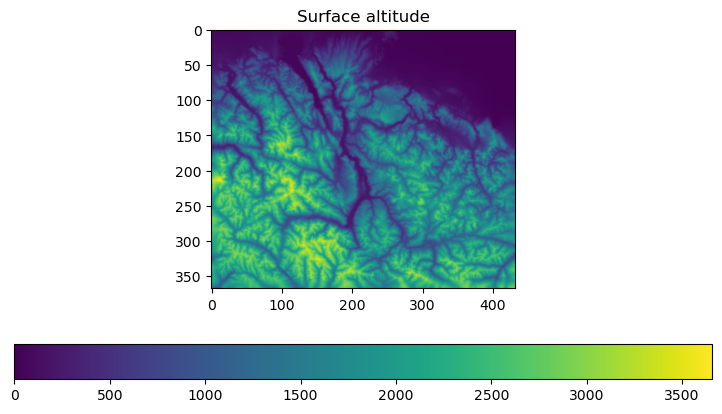

In [8]:
# let's try to plot the surface altitude
fig = plt.figure(figsize=(9, 4.8))

ax = fig.add_subplot()
ax.set_title('Surface altitude')
plt.imshow(sfchgt[:,:])
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()

In [9]:
# The result from the block above 
# should show something that looks like 
# surface altitude, but it's not quite right. 
# The data along the y-axis is inverted.

# Let's verify this by plotting latitude. 
# In the cube for surface altitude, we have 
# grid_latitude and grid_longitude in the 
# dimension coordinates:
print(cubes[0])

surface_altitude / (m)              (grid_latitude: 368; grid_longitude: 432)
    Dimension coordinates:
        grid_latitude                             x                    -
        grid_longitude                            -                    x
    Scalar coordinates:
        forecast_period             0.0 hours
        forecast_reference_time     2025-07-22 12:00:00
        time                        2025-07-22 12:00:00
    Attributes:
        STASH                       m01s00i033
        source                      'Data from Met Office Unified Model'
        um_version                  '13.5'


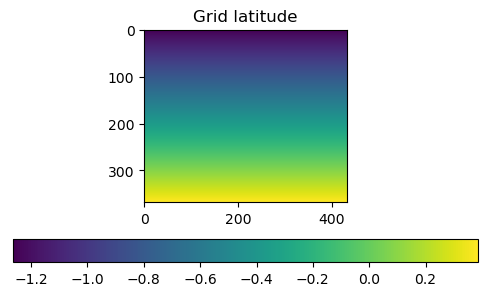

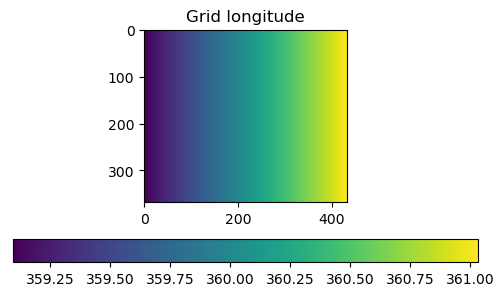

In [10]:
# Let's pull those coordinates:
gridlats = cubes[0].coord('grid_latitude').points
gridlons = cubes[0].coord('grid_longitude').points

# Make meshgrids with them:
xx, yy = np.meshgrid(gridlons, gridlats)

# Let's plot the meshgrids
# First, the one for grid latitude
fig = plt.figure(figsize=(6, 3.2))
ax = fig.add_subplot()
ax.set_title('Grid latitude')
plt.imshow(yy[:,:])
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()

# Second, the one for grid longitude
fig = plt.figure(figsize=(6, 3.2))
ax = fig.add_subplot()
ax.set_title('Grid longitude')
plt.imshow(xx[:,:])
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()

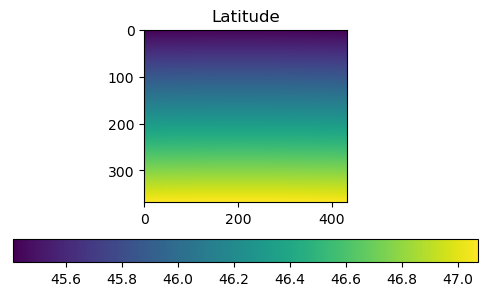

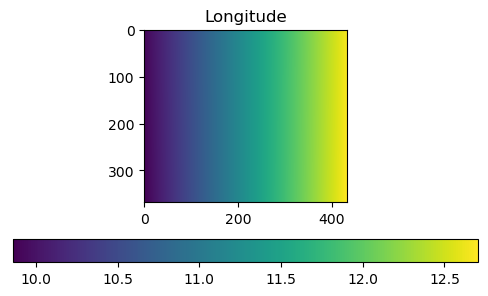

In [11]:
# We can see in the grid latitude plot from the cell above that 
# the grid latitude decreases along the y-axis, but there's another issue
# apparent: The grid latitude/longitude are not the geographical
# values. We need to do more to get the geographical lat/lon on
# the model grid.
# Let's get info on the coordinate system associated with 
# the surface altitude cube, and get a cartopy projection from that:
cs_nat = cubes[0].coord_system()
cs_nat_cart = cs_nat.as_cartopy_projection()

# Next, let's specify a coordinate system to transform the
# grid_latitude and grid_longitude to:
cs_tgt = iris.coord_systems.GeogCS(iris.analysis.cartography.DEFAULT_SPHERICAL_EARTH_RADIUS)
cs_tgt_cart = cs_tgt.as_cartopy_projection()

# Do the transform and apply transposes:
lons, lats, _ = cs_tgt_cart.transform_points(cs_nat_cart, xx, yy).T
lons = np.transpose(lons)
lats = np.transpose(lats)

# Plot the result ...
fig = plt.figure(figsize=(6, 3.2))
ax = fig.add_subplot()
ax.set_title('Latitude')
plt.imshow(lats[:,:])
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()

fig = plt.figure(figsize=(6, 3.2))
ax = fig.add_subplot()
ax.set_title('Longitude')
plt.imshow(lons[:,:])
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()

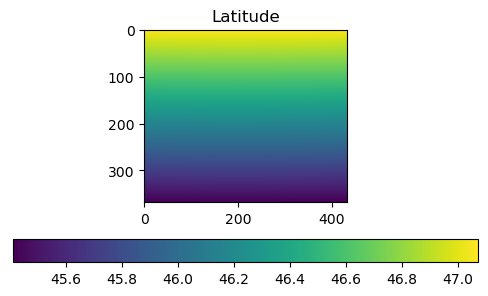

In [12]:
# Looks better, but the field is still inverted along y. 
# We can uninvert it when we show the plot:
fig = plt.figure(figsize=(6, 3.2))
ax = fig.add_subplot()
ax.set_title('Latitude')
plt.imshow(lats[::-1,:]) # <-- uninverting the y-axis
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()

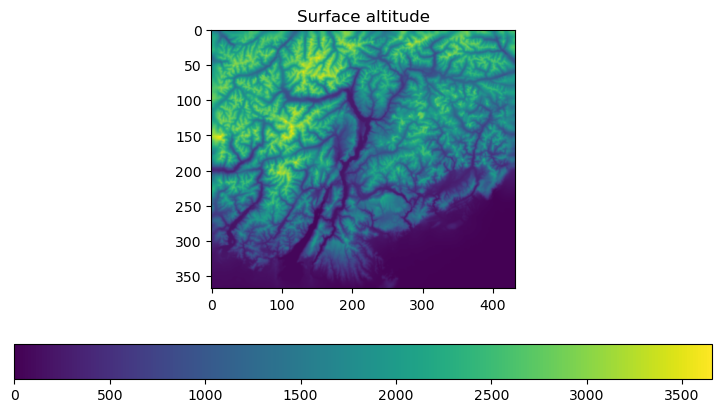

In [13]:
# Finally, let's try again to plot surface altitude
# with data along the y-axis uninverted:
fig = plt.figure(figsize=(9, 4.8))

ax = fig.add_subplot()
ax.set_title('Surface altitude')
plt.imshow(sfchgt[::-1,:]) # <-- uninverting the y-axis
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()